In [1]:
import numpy as np
import pandas as pd

from scipy.stats import norm

import matplotlib.pyplot as plt

In [13]:
PROJECT_ROOT = Path.cwd().parent

DATA = PROJECT_ROOT / "data"

HISTORICAL = DATA / "historical"
OPTIONS = DATA / "options"
REPORT = PROJECT_ROOT / "report"

print("Project Root :", PROJECT_ROOT)
print("Historical   :", HISTORICAL)
print("Options      :", OPTIONS)
print("Report       :", REPORT)

Project Root : c:\Users\Intern Batch 2\Documents\SPY_Options_Project
Historical   : c:\Users\Intern Batch 2\Documents\SPY_Options_Project\data\historical
Options      : c:\Users\Intern Batch 2\Documents\SPY_Options_Project\data\options
Report       : c:\Users\Intern Batch 2\Documents\SPY_Options_Project\report


In [21]:
spy = pd.read_csv(
    HISTORICAL / "SPY_1Y.csv",
    parse_dates=True
)

calls = pd.read_csv(
    OPTIONS / "SPY_Calls.csv"
)

spy.head()

,Close,High,Low,Open,Volume
0,SPY,SPY,SPY,SPY,SPY
1,627.2598266601562,627.2598266601562,622.8288811376781,624.6289433239532,70511000
2,627.4674072265625,629.1784892953694,627.0421268182102,627.6454273719465,71307100
3,630.1180419921875,630.5928227551882,627.8828598800927,628.1301201477661,56865400
4,629.9598999023438,631.0478210681617,628.5752180855901,630.4939604147171,54917100


In [23]:
with open(HISTORICAL / "SPY_1Y.csv", "r") as f:
    for _ in range(10):
        print(f.readline())

Close,High,Low,Open,Volume

SPY,SPY,SPY,SPY,SPY

627.2598266601562,627.2598266601562,622.8288811376781,624.6289433239532,70511000

627.4674072265625,629.1784892953694,627.0421268182102,627.6454273719465,71307100

630.1180419921875,630.5928227551882,627.8828598800927,628.1301201477661,56865400

629.9598999023438,631.0478210681617,628.5752180855901,630.4939604147171,54917100

628.2982788085938,631.6708825055948,627.3883778702398,631.3543820995848,60556300

627.507080078125,630.6917636576716,624.6190364089183,628.9510415464463,80418900

625.1531372070312,632.8379457731452,623.8574957354674,632.4522656090571,103385200

614.9066162109375,619.476041722763,612.5032535330552,619.4364414435403,140103600



In [24]:
spy = pd.read_csv(
    HISTORICAL / "SPY_1Y.csv",
    skiprows=[1]
)

numeric_cols = ["Close", "High", "Low", "Open", "Volume"]

spy[numeric_cols] = spy[numeric_cols].apply(pd.to_numeric)

spy_price = spy["Close"].iloc[-1]

print(spy_price)

747.4099731445312


In [25]:
print(spy.dtypes)

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [26]:
returns = np.log(
    spy["Close"] /
    spy["Close"].shift(1)
)

hv = (
    returns
    .rolling(20)
    .std()
    .iloc[-1]
    * np.sqrt(252)
)

print(f"Historical Volatility = {hv:.4f}")
print(f"Historical Volatility = {hv*100:.2f}%")

Historical Volatility = 0.1064
Historical Volatility = 10.64%


In [27]:
calls["Distance"] = abs(
    calls["strike"] - spy_price
)

atm = calls.loc[
    calls["Distance"].idxmin()
]

atm

contractSymbol              SPY260724C00747000
lastTradeDate        2026-07-24 14:00:03+00:00
strike                                   747.0
lastPrice                                 0.03
bid                                       0.02
ask                                       0.03
change                                   -0.18
percentChange                        -90.00001
volume                                  6323.0
openInterest                             12465
impliedVolatility                     0.109384
inTheMoney                               False
contractSize                           REGULAR
currency                                   USD
Distance                              0.409973
Name: 120, dtype: object

In [28]:
S = spy_price

K = atm["strike"]

market_price = atm["lastPrice"]

sigma = atm["impliedVolatility"]

T = 7 / 365

r = 0.04

bid = atm["bid"]

ask = atm["ask"]

volume = atm["volume"]

open_interest = atm["openInterest"]

spread = ask - bid

In [29]:
def black_scholes_call(S, K, T, r, sigma):

    d1 = (
        np.log(S / K)
        + (r + sigma**2 / 2) * T
    ) / (
        sigma * np.sqrt(T)
    )

    d2 = d1 - sigma * np.sqrt(T)

    return (
        S * norm.cdf(d1)
        - K * np.exp(-r * T) * norm.cdf(d2)
    )

In [30]:
theoretical_price = black_scholes_call(
    S,
    K,
    T,
    r,
    sigma
)

pricing_error = market_price - theoretical_price

print(f"Market Price      : {market_price:.4f}")
print(f"Theoretical Price : {theoretical_price:.4f}")
print(f"Pricing Error     : {pricing_error:.4f}")

Market Price      : 0.0300
Theoretical Price : 5.0221
Pricing Error     : -4.9921


In [31]:
d1 = (
    np.log(S / K)
    + (r + sigma**2 / 2) * T
) / (
    sigma * np.sqrt(T)
)

d2 = d1 - sigma * np.sqrt(T)

call_delta = norm.cdf(d1)

gamma = (
    norm.pdf(d1)
    /
    (
        S
        * sigma
        * np.sqrt(T)
    )
)

vega = (
    S
    * norm.pdf(d1)
    * np.sqrt(T)
    / 100
)

theta = (
    (
        -S
        * norm.pdf(d1)
        * sigma
        /
        (2 * np.sqrt(T))
    )
    -
    (
        r
        * K
        * np.exp(-r * T)
        * norm.cdf(d2)
    )
) / 365

rho = (
    K
    * T
    * np.exp(-r * T)
    * norm.cdf(d2)
    / 100
)

print("Delta :", call_delta)
print("Gamma :", gamma)
print("Vega  :", vega)
print("Theta :", theta)
print("Rho   :", rho)

Delta : 0.5376188873327399
Gamma : 0.035079918583850817
Vega  : 0.4110881500722779
Theta : -0.3646736542739556
Rho   : 0.07609854912952264


In [32]:
summary = pd.DataFrame({

    "Metric": [

        "SPY Price",
        "Strike",
        "Market Price",
        "Theoretical Price",
        "Pricing Error",
        "Historical Volatility",
        "Implied Volatility",
        "Delta",
        "Gamma",
        "Vega",
        "Theta",
        "Rho",
        "Volume",
        "Open Interest",
        "Bid",
        "Ask",
        "Bid-Ask Spread"

    ],

    "Value": [

        S,
        K,
        market_price,
        theoretical_price,
        pricing_error,
        hv,
        sigma,
        call_delta,
        gamma,
        vega,
        theta,
        rho,
        volume,
        open_interest,
        bid,
        ask,
        spread

    ]

})

summary

,Metric,Value
0,SPY Price,747.409973
1,Strike,747.000000
2,Market Price,0.030000
3,Theoretical Price,5.022141
4,Pricing Error,-4.992141
5,Historical Volatility,0.106446
6,Implied Volatility,0.109384
7,Delta,0.537619
8,Gamma,0.035080
9,Vega,0.411088


In [33]:
summary.to_csv(
    HISTORICAL / "SPY_Option_Summary.csv",
    index=False
)

print("Summary saved successfully.")

Summary saved successfully.


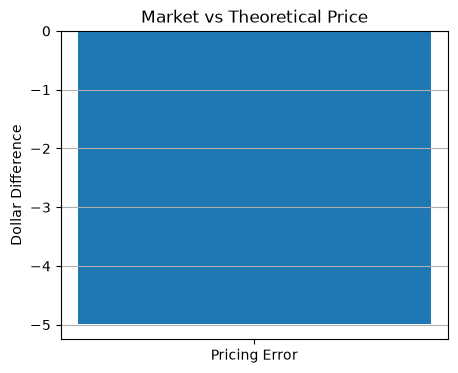

In [34]:
plt.figure(figsize=(5,4))

plt.bar(
    ["Pricing Error"],
    [pricing_error]
)

plt.ylabel("Dollar Difference")

plt.title("Market vs Theoretical Price")

plt.grid(axis="y")

plt.savefig(
    REPORT / "Pricing_Error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

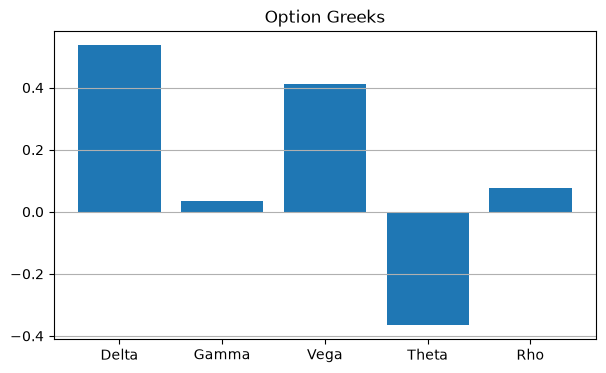

In [35]:
greeks = {

    "Delta": call_delta,
    "Gamma": gamma,
    "Vega": vega,
    "Theta": theta,
    "Rho": rho

}

plt.figure(figsize=(7,4))

plt.bar(
    greeks.keys(),
    greeks.values()
)

plt.title("Option Greeks")

plt.grid(axis="y")

plt.savefig(
    REPORT / "Greeks_Summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
liquidity = pd.DataFrame({

    "Metric": [

        "Volume",
        "Open Interest",
        "Bid",
        "Ask",
        "Bid-Ask Spread"

    ],

    "Value": [

        volume,
        open_interest,
        bid,
        ask,
        spread

    ]

})

liquidity

,Metric,Value
0,Volume,6323.00
1,Open Interest,12465.00
2,Bid,0.02
3,Ask,0.03
4,Bid-Ask Spread,0.01


In [37]:
volatility = pd.DataFrame({

    "Metric": [

        "Historical Volatility",
        "Implied Volatility"

    ],

    "Value": [

        hv,
        sigma

    ]

})

volatility

,Metric,Value
0,Historical Volatility,0.106446
1,Implied Volatility,0.109384


In [38]:
print("----------- SPY OPTION ANALYSIS -----------\n")

print(f"Current SPY Price       : {S:.2f}")
print(f"Strike Price            : {K:.2f}")

print()

print(f"Market Price            : {market_price:.2f}")
print(f"Theoretical Price       : {theoretical_price:.2f}")
print(f"Pricing Error           : {pricing_error:.4f}")

print()

print(f"Historical Volatility   : {hv*100:.2f}%")
print(f"Implied Volatility      : {sigma*100:.2f}%")

print()

print(f"Delta                   : {call_delta:.4f}")
print(f"Gamma                   : {gamma:.6f}")
print(f"Vega                    : {vega:.4f}")
print(f"Theta                   : {theta:.4f}")
print(f"Rho                     : {rho:.4f}")

print()

print(f"Volume                  : {volume}")
print(f"Open Interest           : {open_interest}")
print(f"Bid                     : {bid}")
print(f"Ask                     : {ask}")
print(f"Bid-Ask Spread          : {spread:.2f}")

print("\nAnalysis complete.")

----------- SPY OPTION ANALYSIS -----------

Current SPY Price       : 747.41
Strike Price            : 747.00

Market Price            : 0.03
Theoretical Price       : 5.02
Pricing Error           : -4.9921

Historical Volatility   : 10.64%
Implied Volatility      : 10.94%

Delta                   : 0.5376
Gamma                   : 0.035080
Vega                    : 0.4111
Theta                   : -0.3647
Rho                     : 0.0761

Volume                  : 6323.0
Open Interest           : 12465
Bid                     : 0.02
Ask                     : 0.03
Bid-Ask Spread          : 0.01

Analysis complete.
